# WEEK -08: K-Nearest Neighbour (K-NN) & ID-3 Decision Tree 

 Chirag Rao K V

 240962180
 
 AIML B 16

In [90]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier

In [91]:
data =[
    [180,7,"Apple"],
    [200,6,"Apple"],
    [150,4,"Orange"],
    [170,5,"Orange"],
    [160,6,"Apple"],
    [140,3,"Orange"]
]
data = pd.DataFrame(data,columns=["weight","sweetness","fruit"])

In [92]:
class KNN:
    def __init__(self,data):
        self.data = data
        self.points = self.data[["weight", "sweetness"]].values
    
    def predict(self, p, k):
        
        distances = np.sqrt(
            np.sum((self.points - np.array(p)) ** 2, axis=1)
        )
        indices = np.argsort(distances)[:k]
        labels = self.data.iloc[indices]["fruit"]
        
        return labels.mode()[0]
    
    def distances(self,p):
        euclidean = np.sqrt(np.sum((self.points - p) ** 2, axis=1))
        manhattan = np.sum(np.abs(self.points - p), axis=1)
        minkowski = np.sum(np.abs(self.points - p) ** 3, axis=1) ** (1/3)
        print(f"eucledian_distance:\t{euclidean}\nManhattan distance:\t{manhattan}\nminkowski:\t{minkowski}")
        


In [93]:
knn = KNN(data)
knn.predict((165, 5.5), 3)

'Orange'

In [94]:
knn.distances((165, 5.5))

eucledian_distance:	[15.07481343 35.00357125 15.07481343  5.02493781  5.02493781 25.12468905]
Manhattan distance:	[16.5 35.5 16.5  5.5  5.5 27.5]
minkowski:	[15.00499833 35.00003401 15.00499833  5.00166611  5.00166611 25.00833056]


In [95]:
knn.predict((165, 5.5), 3)

'Orange'

In [96]:
for i in range(1,6):
    print(f"k = {i}:{knn.predict((165, 5.5), i)}")

k = 1:Orange
k = 2:Apple
k = 3:Orange
k = 4:Apple
k = 5:Orange


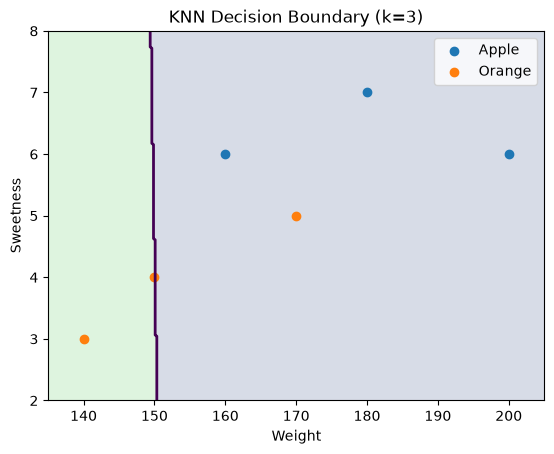

In [97]:
apple = data[data["fruit"] == "Apple"]
x_min, x_max = 135, 205
y_min, y_max = 2, 8
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
Z = np.array([
    knn.predict((x, y), k=2)
    for x, y in zip(xx.ravel(), yy.ravel())
])
Z = Z.reshape(xx.shape)
Z_num = np.where(Z == "Apple", 0, 1)
plt.contourf(
    xx, yy, Z_num,
    alpha=0.2,
    levels=[-0.5, 0.5, 1.5]
)
plt.scatter(
    apple["weight"],
    apple["sweetness"],
    label="Apple"
)
orange = data[data["fruit"] == "Orange"]
plt.scatter(
    orange["weight"],
    orange["sweetness"],
    label="Orange"
)
plt.contour(
    xx, yy, Z_num,
    levels=[0.5],
    linewidths=2
)
plt.xlabel("Weight")
plt.ylabel("Sweetness")
plt.title("KNN Decision Boundary (k=3)")
plt.legend()
plt.show()



# Q2

In [98]:
df = pd.DataFrame({
    "Age":[30,45,50,35,60,55,40,25,65,45],
    "BP":["H","L","H","L","H","L","H","L","H","L"],
    "Chol":["H","N","H","N","H","N","H","N","H","N"],
    "D":["S","H","S","H","S","H","S","H","S","H"]
})

def entropy(y):
    p = y.value_counts(normalize=True)
    return -sum(p*np.log2(p))

def IG(df, col):
    return entropy(df.D) - sum(
        len(g)/len(df)*entropy(g.D)
        for _,g in df.groupby(col)
    )

print("Entropy =", entropy(df.D))
print("BP IG =", IG(df,"BP"))
print("Chol IG =", IG(df,"Chol"))
print("Age IG =", IG(df,"Age"))

Entropy = 1.0
BP IG = 1.0
Chol IG = 1.0
Age IG = 1.0


In [99]:
# only root node as its alr pure hence no need to proceed
def predict(age, bp, cholesterol):
    if bp == "High":
        return "Sick"
    else:
        return "Healthy"
print("Prediction:", predict(50, "Low", "Normal"))

Prediction: Healthy


Feature importance:
Age 1.0
BP 0.0
Chol 0.0


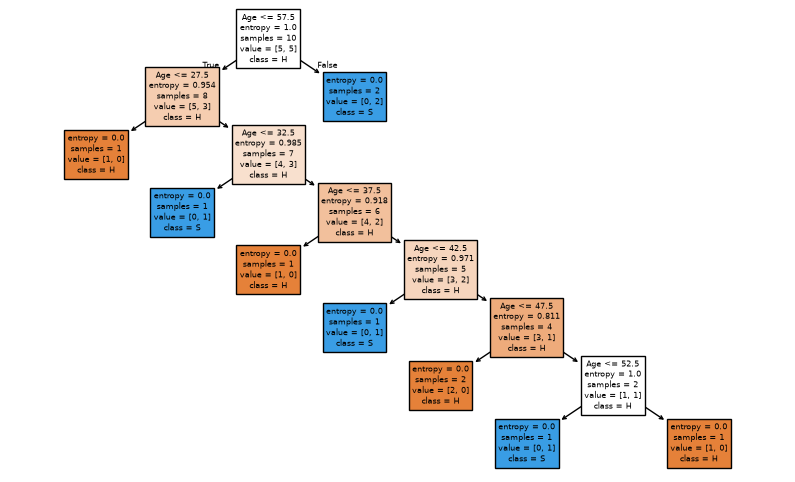

In [100]:

df["BP"] = df["BP"].map({"Low": 0, "High": 1})
df["Chol"] = df["Chol"].map({"Normal": 0, "High": 1})
X = df[["Age", "BP", "Chol"]]
y = df["D"]
tree = DecisionTreeClassifier(
    criterion="entropy",
    random_state=0
)
tree.fit(X, y)
print("Feature importance:")
for feature, importance in zip(X.columns, tree.feature_importances_):
    print(feature, importance)
patient = [[50, 0, 0]]
plt.figure(figsize=(10, 6))
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=tree.classes_,
    filled=True
)
plt.show()

In [101]:
print(tree.predict([[10, 1, 1]])[0])

H


/home/student/aiml_b/myenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Additional Distance


 euclidean
K = 2 -> Bad
K = 3 -> Bad
K = 4 -> Bad

 manhattan
K = 2 -> Good
K = 3 -> Bad
K = 4 -> Good

 minkowski
K = 2 -> Bad
K = 3 -> Bad
K = 4 -> Bad


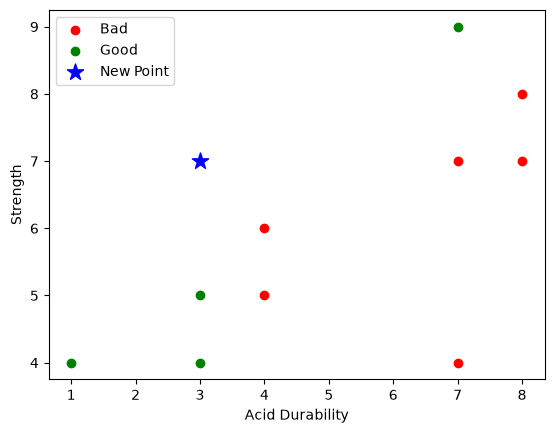

In [102]:
data = np.array([
    [7, 7, "Bad"],
    [7, 4, "Bad"],
    [3, 4, "Good"],
    [1, 4, "Good"],
    [4, 5, "Bad"],
    [3, 5, "Good"],
    [4, 6, "Bad"],
    [8, 7, "Bad"],
    [7, 9, "Good"],
    [8, 8, "Bad"]
], dtype=object)

def distance(p1, p2, metric="euclidean"):
    if metric == "euclidean":
        return np.sqrt(np.sum((p1 - p2) ** 2))

    if metric == "manhattan":
        return np.sum(np.abs(p1 - p2))

    if metric == "minkowski":
        p = 3
        return np.sum(np.abs(p1 - p2) ** p) ** (1/p)


def predict(point, k, metric="euclidean"):
    distances = []

    for row in data:
        p = np.array(row[:2], dtype=float)
        d = distance(point, p, metric)
        distances.append((d, row[2]))

    distances.sort()

    nearest = distances[:k]

    # Distance-weighted voting
    votes = {"Good": 0, "Bad": 0}

    for d, label in nearest:
        votes[label] += 1 / (d + 1e-9)

    return max(votes, key=votes.get)


point = np.array([3, 7])

for metric in ["euclidean", "manhattan", "minkowski"]:
    print("\n", metric)

    for k in [2, 3, 4]:
        print("K =", k, "->", predict(point, k, metric))


# Plot
bad = data[data[:, 2] == "Bad"]
good = data[data[:, 2] == "Good"]

plt.scatter(bad[:, 0].astype(float), bad[:, 1].astype(float),
            color="red", label="Bad")

plt.scatter(good[:, 0].astype(float), good[:, 1].astype(float),
            color="green", label="Good")

plt.scatter(3, 7, color="blue", marker="*", s=150, label="New Point")

plt.xlabel("Acid Durability")
plt.ylabel("Strength")
plt.legend()
plt.show()

In [103]:
X = np.array([
    [7,7],
    [7,4],
    [3,4],
    [1,4],
    [4,5],
    [3,5],
    [4,6],
    [8,7],
    [7,9],
    [8,8]
])

y = np.array([
    "Bad", "Bad", "Good", "Good", "Bad",
    "Good", "Bad", "Bad", "Good", "Bad"
])

point = np.array([[3,7]])

for metric in ["euclidean", "manhattan", "minkowski"]:

    print("\n", metric)

    for k in [2,3,4]:

        model = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric,
            p=3
        )

        model.fit(X, y)

        print("K =", k, "->", model.predict(point)[0])


 euclidean
K = 2 -> Bad
K = 3 -> Bad
K = 4 -> Bad

 manhattan
K = 2 -> Bad
K = 3 -> Good
K = 4 -> Bad

 minkowski
K = 2 -> Bad
K = 3 -> Bad
K = 4 -> Bad


In [107]:
X = np.array([
[19,19000],[35,20000],[26,43000],[27,57000],[19,76000],
[27,58000],[27,84000],[32,150000],[25,33000],[35,65000],
[26,80000],[26,52000],[20,86000],[32,18000],[18,82000],
[29,80000],[47,25000],[45,26000],[46,28000],[48,29000],
[45,22000],[47,49000]])

y = np.array([0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,1,1,1,1])

m, s = X.mean(0), X.std(0)
X = (X-m)/s

def predict(p,k,metric):
    if metric=="euclidean":
        d=np.sqrt(((X-p)**2).sum(1))
    elif metric=="manhattan":
        d=np.abs(X-p).sum(1)
    else:
        d=(np.abs(X-p)**3).sum(1)**(1/3)

    return max(y[np.argsort(d)[:k]], key=list(y[np.argsort(d)[:k]]).count)

p=(np.array([30,50000])-m)/s

for metric in ["euclidean","manhattan","minkowski"]:
    for k in [2,3,4]:
        print(metric,k,predict(p,k,metric))

euclidean 2 0
euclidean 3 0
euclidean 4 0
manhattan 2 0
manhattan 3 0
manhattan 4 0
minkowski 2 0
minkowski 3 0
minkowski 4 0


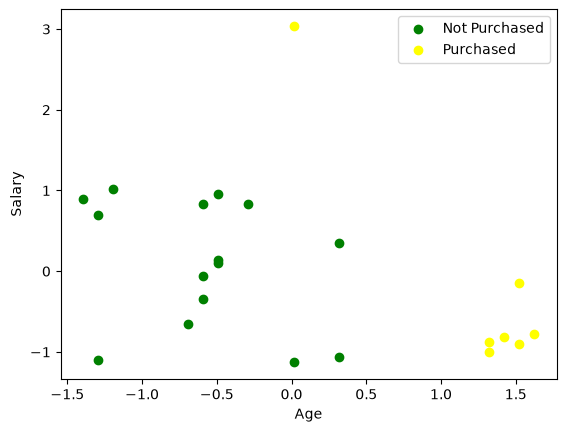

In [108]:
plt.scatter(X[y==0,0],X[y==0,1],c="green",label="Not Purchased")
plt.scatter(X[y==1,0],X[y==1,1],c="yellow",label="Purchased")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.legend()
plt.show()

In [110]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

p = scaler.transform([[30,50000]])

for metric in ["euclidean","manhattan","minkowski"]:
    for k in [2,3,4]:
        model = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric,
            p=3
        )
        model.fit(X,y)
        print(metric,k,model.predict(p)[0])

euclidean 2 0
euclidean 3 0
euclidean 4 0
manhattan 2 1
manhattan 3 1
manhattan 4 1
minkowski 2 0
minkowski 3 0
minkowski 4 0


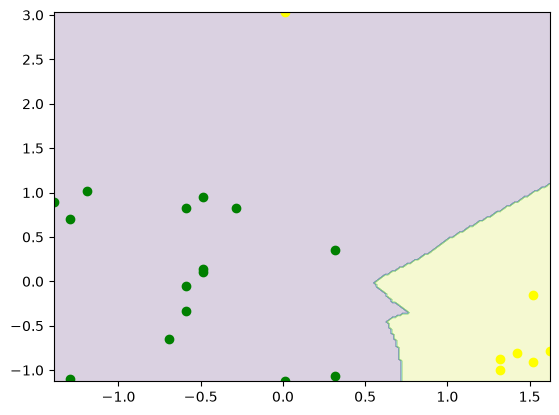

In [111]:
xx,yy=np.meshgrid(
    np.linspace(X[:,0].min(),X[:,0].max(),200),
    np.linspace(X[:,1].min(),X[:,1].max(),200)
)

Z=model.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)

plt.contourf(xx,yy,Z,alpha=.2)
plt.scatter(X[y==0,0],X[y==0,1],c="green")
plt.scatter(X[y==1,0],X[y==1,1],c="yellow")
plt.show()